In [1]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"

import torch
import xformers
import gc
gc.collect()
torch.cuda.empty_cache()

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("PyTorch Version:", torch.__version__)
print("xFormers Version:", xformers.__version__)

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
PyTorch Version: 2.6.0+cu124
xFormers Version: 0.0.29.post3


In [2]:
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
DATA_FILE = "phase1b_ami_train_reasoning.jsonl" 
BASE_MODEL_DIR = "base_llama3_model"
ADAPTER_DIR = "adapters/AMI_Adapter"
GGUF_DIR = "adapters/AMI_Adapter_GGUF" # CPU safe model

# Base Model Info
HF_MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 2048 # Maximum context length
LOAD_IN_4BIT = True   #  quantized model

In [4]:
# OFFLINE PORTABILITY LOGIC

if not os.path.exists(BASE_MODEL_DIR):
    print(f"Base model not found locally. Downloading {HF_MODEL_NAME} from Hugging Face...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = HF_MODEL_NAME,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype = None,
        load_in_4bit = LOAD_IN_4BIT,
    )
    print(f"Saving raw base model to {BASE_MODEL_DIR} for future offline use...")
    model.save_pretrained(BASE_MODEL_DIR)
    tokenizer.save_pretrained(BASE_MODEL_DIR)
else:
    print(f"Loading Base Model OFFLINE from local folder: {BASE_MODEL_DIR}...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = BASE_MODEL_DIR,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype = None,
        load_in_4bit = LOAD_IN_4BIT,
    )

Loading Base Model OFFLINE from local folder: base_llama3_model...
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 4060 Laptop GPU. Num GPUs = 1. Max memory: 7.996 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [5]:
# Loading Llama 3 3B via the Unsloth optimized wrapper in 4 bit quantized format.
# PEFT freezes the model. Using frozen model
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, 
    
    # q_proj, k_proj, v_proj, o_proj - Help the model focus on important words (attention)
    # gate_proj, up_proj, down_proj - Help the model think and reason (Multi Layer Perception)(MLP layers)
    target_modules = ["q_proj", "v_proj"], # both are enough for generating reasons
    
    lora_alpha = 16,
    lora_dropout = 0, 
    bias = "none",    
    use_gradient_checkpointing = True, # no pytorch checkpoint since not optimized for unsloth
    random_state = 3407,
)

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.2.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [6]:
print("Loading and Validating Data...")
dataset = load_dataset("json", data_files = DATA_FILE, split = "train")

# Data Validation
def is_valid_sample(example):
    out = example.get("output")
    # Drop if None, empty, or a placeholder
    if not out or str(out).strip() == "" or out == "TO_BE_GENERATED":
        return False
    return True

Loading and Validating Data...


In [7]:
# Apply the filter before formatting
dataset = dataset.filter(is_valid_sample)
print(f" Clean samples ready for training: {len(dataset)}")

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are an intelligent AI meeting assistant. Analyze the transcript and extract the factual information.
CRITICAL RULES:
1. List EVERY single speaker who talks in the text (e.g., A, B, C). Do not miss any.
2. Extract Main decisions using bullet points (-).
3. Extract Action items using bullet points (-).
4. The Summary must be exactly 1 to 2 strictly factual sentence. Do NOT invent details. Do NOT write fake dialogue.

Format your output EXACTLY like this:
Thought: Key speakers: [List speakers]
Main decisions: 
- [point 1]
Action items: 
- [point 1]
Summary: [Final summary]

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token # end of sentence (eos) to predict the stopping or else model generates forever


 Clean samples ready for training: 145


In [8]:
def formatting_prompts_func(examples):
    inputs = examples["input"]
    outputs = examples["output"]
    texts = []
    for input_text, output_text in zip(inputs, outputs):
        text = alpaca_prompt.format(input_text, output_text) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts }

# Apply the formatting
dataset = dataset.map(formatting_prompts_func, batched = True)

# the Validation Split (10% for evaluation)
split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"] 

In [9]:
print(f"Starting Training for {ADAPTER_DIR}...")

# SFTTrainer Specialized for LLMs better than Standard trainer
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    dataset_num_proc = 2, # uses 2 CPUs
    packing = False, # dont combine multiple samples (packing - harder to debug)
    
    args = TrainingArguments(
        per_device_train_batch_size = 1, # process 1 sample at a time
        gradient_accumulation_steps = 8, # gradients to simulate batch size of 8

        # used max_steps instead of epochs because it gives control over training duration, especially with small datasets
        # to control GPU
        warmup_steps = 5,
        max_steps = 150, # ~3 epochs for AMI dataset size
        learning_rate = 2e-4, # standard LoRA lr
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(), # uses bfloat16 (brain float) on RTX 4060

        # evaluate every 10 stpes and logs every 5 steps
        eval_strategy = "steps",
        eval_steps = 15,
        logging_steps = 5,
        
        optim = "paged_adamw_8bit", # a 8bit Adam optimizer
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = ADAPTER_DIR,
        overwrite_output_dir = True, # Overwrites the old, broken adapter
    ),
)

# Start training
trainer.train()

Starting Training for adapters/AMI_Adapter...


Unsloth: Tokenizing ["text"]:   0%|          | 0/130 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/15 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 130 | Num Epochs = 9 | Total steps = 150
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 3,217,337,344 (0.14% trained)


Step,Training Loss,Validation Loss
15,2.684300,2.553940
30,2.347200,2.209375
45,2.106300,1.985068
60,1.970900,1.955180
75,1.955300,1.934266
90,1.916200,1.923823
105,1.986100,1.916350
120,1.895600,1.910907
135,1.900600,1.907774
150,1.942400,1.907059


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=150, training_loss=2.10846373240153, metrics={'train_runtime': 943.1143, 'train_samples_per_second': 1.272, 'train_steps_per_second': 0.159, 'total_flos': 1.9983248293625856e+16, 'train_loss': 2.10846373240153, 'epoch': 8.861538461538462})

In [10]:
print(f"Saving LoRA Adapter to {ADAPTER_DIR}...")
model.save_pretrained(ADAPTER_DIR) 
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Run Complete! AMI Adapter successfully trained.")

Saving LoRA Adapter to adapters/AMI_Adapter...
Run Complete! AMI Adapter successfully trained.


In [11]:
# # EXPORT FOR CPU (GGUF FORMAT)

# print("\nExporting to GGUF for CPU/Ollama use...")
# model.save_pretrained_gguf(
#     GGUF_DIR, 
#     tokenizer, 
#     quantization_method = "q4_k_m" # Balanced quality/speed for CPUs
# )
# print("GGUF Export Complete! You can now run this specific file on ANY laptop using Ollama or CPU only software.")

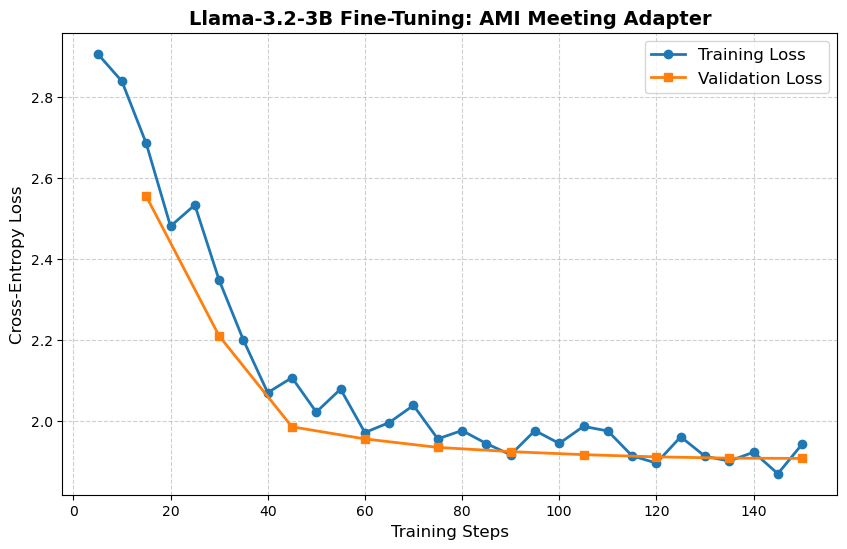

In [12]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    # validation loss
    elif "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", marker="o", linewidth=2)

if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="#ff7f0e", marker="s", linewidth=2)

plt.title("Llama-3.2-3B Fine-Tuning: AMI Meeting Adapter", fontsize=14, fontweight="bold")
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig("AMI_Loss_Curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
# HARD SHUTDOWN & UNLOAD FROM GPU

import torch
import gc

print("Initiating VRAM Hard-Shutdown for Local Models...")

# 1. Track memory before cleanup
if torch.cuda.is_available():
    vram_before = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM Allocated Before: {vram_before:.2f} GB")

# 2. List of every heavy object that might be trapped in memory
heavy_objects = [
    'model', 'tokenizer', 'trainer', 'bertscore', 'rouge', 
    'dataset', 'train_dataset', 'eval_dataset', 'split_dataset',
    'inputs', 'outputs'
]

# 3. Delete them dynamically if they exist
for obj in heavy_objects:
    if obj in globals():
        print(f"Unloading '{obj}' from memory...")
        del globals()[obj]

# 4. Force aggressive Garbage Collection (Run twice to clear circular references)
gc.collect()
gc.collect()

# 5. Flush the GPU Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()  # Clears memory shared between backend processes
    torch.cuda.synchronize()  # Waits for all GPU operations to completely finish
    
    # Track memory after cleanup
    vram_after = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM Allocated After:  {vram_after:.2f} GB")

print("\nGPU Memory Cleared. Your VRAM is now completely empty!")

Initiating VRAM Hard-Shutdown for Local Models...
VRAM Allocated Before: 2.19 GB
Unloading 'model' from memory...
Unloading 'tokenizer' from memory...
Unloading 'trainer' from memory...
Unloading 'dataset' from memory...
Unloading 'train_dataset' from memory...
Unloading 'eval_dataset' from memory...
Unloading 'split_dataset' from memory...
VRAM Allocated After:  0.75 GB

GPU Memory Cleared. Your VRAM is now completely empty!
